# 04 · Test evaluation (days 51–60, touched once)

PR-AUC, recall at fixed false-positive rates, per-scenario and per-role recall, victim money protected
(assumption-based), friction for honest customers, fairness by group, feature-group ablation, SHAP, and the
planted demo scenarios with Bangla warnings.

In [1]:
# --- setup: find the repo root (works locally, in Colab and on Kaggle) -------------------------
import os, sys, shutil, subprocess
from pathlib import Path

REPO_URL = ""          # optional: your GitHub repo URL, cloned if the code is not found
ROOT = None
for cand in [Path.cwd(), Path.cwd().parent, *Path("/kaggle/input").glob("*")] if Path("/kaggle/input").exists() else [Path.cwd(), Path.cwd().parent]:
    if (cand / "src" / "pipeline.py").exists():
        ROOT = cand
        break
if ROOT is None and REPO_URL:
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "prohori"], check=True)
    ROOT = Path("prohori").resolve()
assert ROOT is not None, "Put this notebook next to the repo (or add the repo as a Kaggle dataset / set REPO_URL)"
if str(ROOT).startswith("/kaggle/input"):          # Kaggle inputs are read-only: work on a copy
    dst = Path("/kaggle/working/prohori")
    shutil.copytree(ROOT, dst, dirs_exist_ok=True)
    ROOT = dst
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("repo root:", ROOT)

repo root: H:\Tacos Projects\Hackathon\Asking for a Friend


In [2]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40, "display.width", 200)
from src.common.config import load_config, resolve
from src.models import plots
plots.style()
cfg = load_config()                 # config.yaml (seed 42, full scale)
REPORTS = resolve(cfg, "reports_dir")

In [3]:
RERUN = False
if RERUN or not (REPORTS / "metrics_test.json").exists():
    from src.models.evaluate import evaluate
    evaluate(cfg)
m = json.loads((REPORTS / "metrics_test.json").read_text(encoding="utf-8"))
pd.DataFrame(m["comparison"]).set_index("model")

,pr_auc,roc_auc,recall_at_fpr_0p1,recall_at_fpr_0p5,recall_at_fpr_2,precision_at_recall_50,n,positives
model,,,,,,,,
rules baseline,0.1880,0.8960,0.0708,0.2003,0.3836,0.1242,66234,734
logistic regression,0.8986,0.9974,0.7561,0.9237,0.9700,0.9545,66234,734
XGBoost,0.9614,0.9978,0.9319,0.9550,0.9796,1.0000,66234,734
LightGBM,0.9622,0.9985,0.9210,0.9496,0.9809,1.0000,66234,734
Isolation Forest,0.4052,0.8863,0.2738,0.3910,0.5204,0.2593,66234,734
graph rules,0.1419,0.7877,0.0835,0.2006,0.3383,0.0362,66234,734
Prohori fused score,0.9622,0.9985,0.9210,0.9496,0.9809,1.0000,66234,734


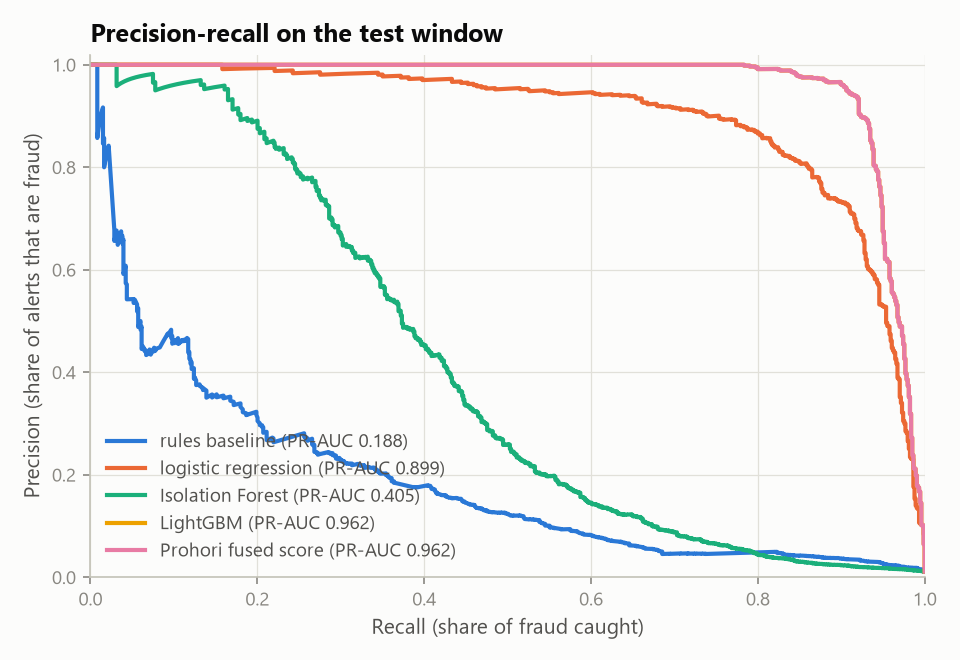

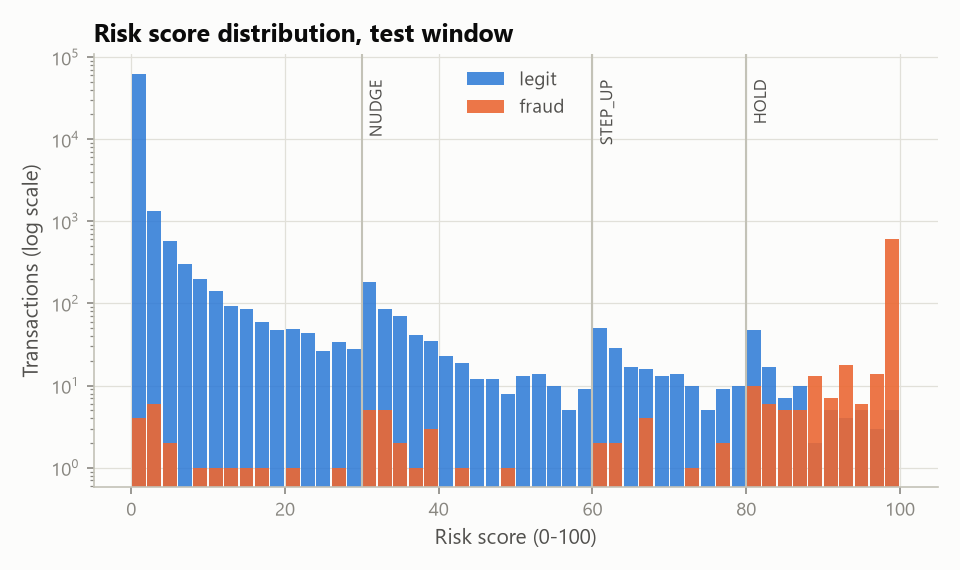

{
 "NUDGE+": {
  "alerts": 1551,
  "tp": 715,
  "fp": 836,
  "precision": 0.461,
  "recall": 0.9741,
  "fpr": 0.01276
 },
 "STEP_UP+": {
  "alerts": 975,
  "tp": 697,
  "fp": 278,
  "precision": 0.7149,
  "recall": 0.9496,
  "fpr": 0.00424
 },
 "HOLD+": {
  "alerts": 775,
  "tp": 673,
  "fp": 102,
  "precision": 0.8684,
  "recall": 0.9169,
  "fpr": 0.00156
 },
 "band_counts": {
  "ALLOW": 64683,
  "NUDGE": 576,
  "STEP_UP": 200,
  "HOLD": 775
 }
}


In [4]:
display(Image(filename=str(REPORTS / "figures" / "pr_curves_test.png")))
display(Image(filename=str(REPORTS / "figures" / "score_distribution_test.png")))
print(json.dumps(m["bands"], indent=1))

## Which scams get caught

,scenario,fraud_txns,cases,recall_nudge,recall_stepup,recall_hold,case_caught_stepup
0,S1,174,36,1.000,1.000,0.989,1.000
1,S2,151,9,1.000,1.000,0.980,1.000
2,S3,66,11,0.985,0.985,0.924,1.000
3,S5,136,13,0.882,0.779,0.743,1.000
4,S6,70,12,1.000,1.000,1.000,1.000
5,S7,93,34,0.978,0.935,0.849,0.971
6,S8,44,7,1.000,1.000,0.955,1.000


,fraud_role,n,recall_nudge,recall_stepup,recall_hold
0,buyer_payment,93,0.828,0.688,0.634
1,card_add_money,20,1.000,1.000,1.000
2,cashout,8,1.000,1.000,1.000
3,coerced_send,37,0.973,0.865,0.676
4,collector_cashout,19,1.000,1.000,1.000
5,mule_cashout,180,1.000,1.000,1.000
6,mule_hop,76,0.987,0.987,0.868
7,recipient_cashout,38,0.974,0.974,0.974
8,seller_cashout,43,1.000,0.977,0.977
9,takeover_drain,102,1.000,1.000,1.000


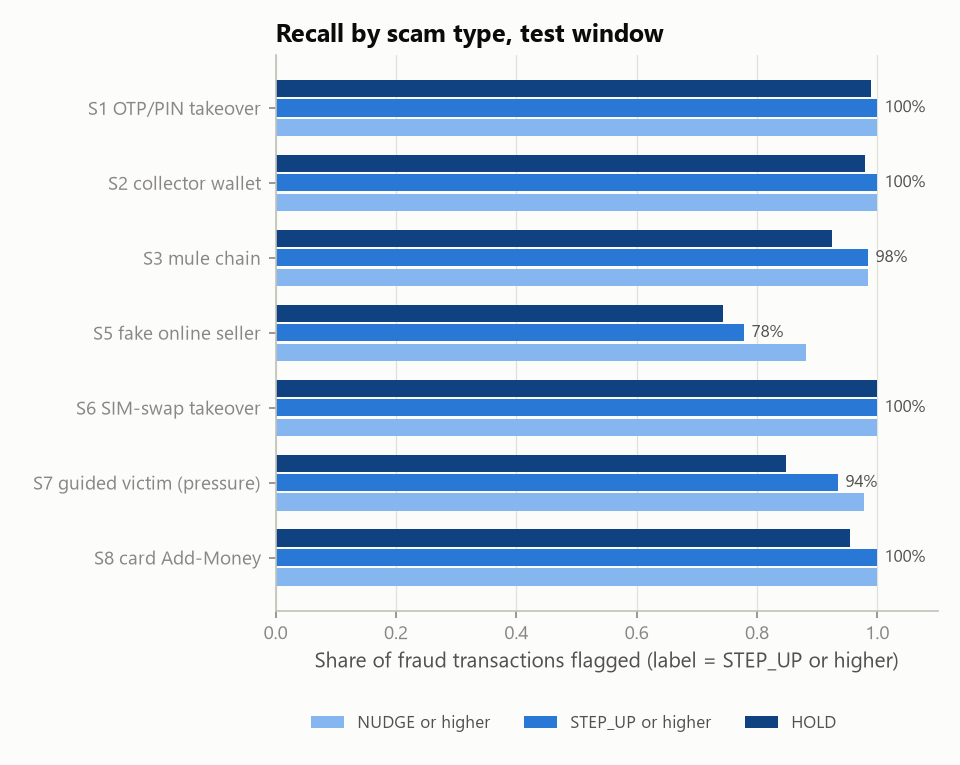

In [5]:
display(pd.DataFrame(m["per_scenario"]))
display(pd.DataFrame(m["per_role"]))
display(Image(filename=str(REPORTS / "figures" / "recall_by_scenario_test.png")))

## Impact and friction

In [6]:
print(json.dumps(m["impact"], indent=1))
print(json.dumps(m["friction"], indent=1))

{
 "victim_side_txns": 370,
 "victim_side_recall_nudge": 0.954,
 "victim_side_recall_stepup": 0.908,
 "victim_side_recall_hold": 0.868,
 "victim_loss_tk": 2526620,
 "expected_prevented_tk": 2401775,
 "expected_prevented_share": 0.951,
 "stop_rate_assumption": {
  "ALLOW": 0.0,
  "NUDGE": 0.3,
  "STEP_UP": 0.7,
  "HOLD": 1.0
 },
 "cases_in_test": 121,
 "cases_caught_stepup": 0.992,
 "cases_caught_nudge": 1.0
}
{
 "legit_customers": 10292,
 "customers_nudged_share": 0.0734,
 "customers_stepup_share": 0.0259,
 "customers_held_share": 0.0095,
 "legit_txn_share_by_band": {
  "ALLOW": 0.98724,
  "NUDGE": 0.00852,
  "STEP_UP": 0.00269,
  "HOLD": 0.00156
 },
 "alerts_per_day": {
  "HOLD": 77.5,
  "STEP_UP": 20.0,
  "NUDGE": 57.6
 },
 "analyst_hours_manual": 258.3,
 "analyst_hours_with_copilot": 38.8
}


## Fairness (protected attributes are not model inputs; we audit false positives per group)

,attribute,group,legit_txns,fraud_txns,fpr_nudge,fpr_stepup,fpr_nudge_ratio,fpr_stepup_ratio,tpr_stepup,flag
0,gender,F,25165,291,0.01121,0.00326,0.88,0.77,0.935,False
1,gender,M,40335,443,0.01373,0.00486,1.08,1.14,0.959,False
2,age_band,18-24,14934,203,0.00924,0.00275,0.72,0.65,0.946,False
3,age_band,25-34,21167,249,0.01243,0.00397,0.97,0.94,0.980,False
4,age_band,35-44,15596,169,0.01340,0.00468,1.05,1.10,0.923,False
5,age_band,45-59,10669,88,0.01697,0.00544,1.33,1.28,0.920,True
6,age_band,60+,3134,25,0.01436,0.00702,1.12,1.65,0.960,True
7,urban_rural,rural,30854,356,0.01209,0.00412,0.95,0.97,0.955,False
8,urban_rural,urban,34646,378,0.01336,0.00436,1.05,1.03,0.944,False
9,cust_channel,APP,55890,642,0.01297,0.00440,1.02,1.04,0.963,False


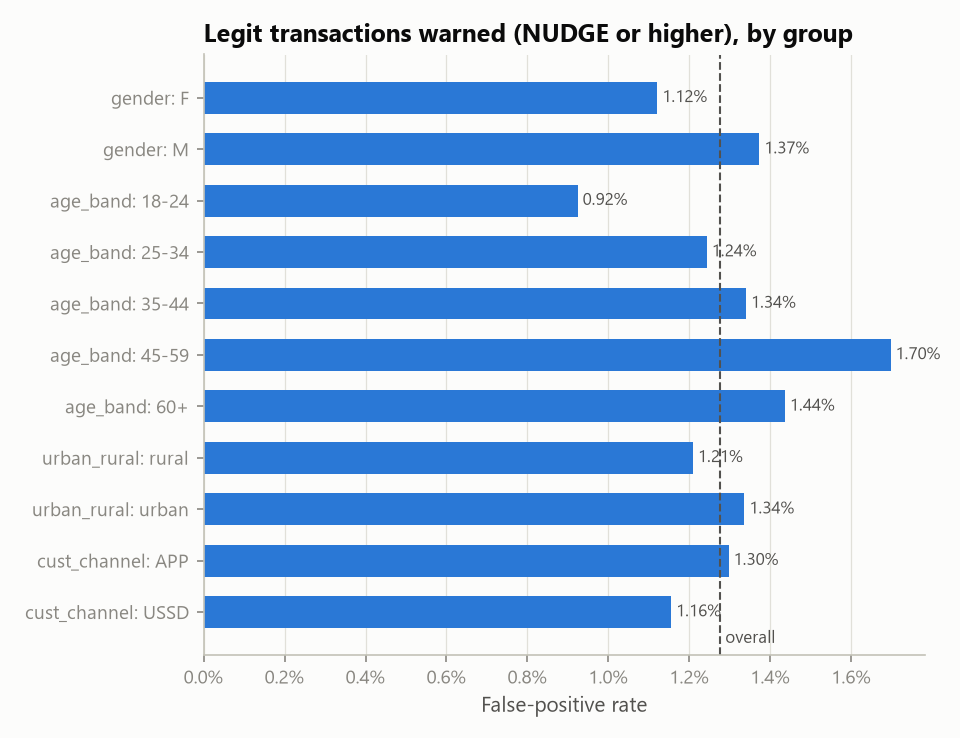

In [7]:
fair = pd.read_csv(REPORTS / "fairness.csv")
display(fair[fair.attribute.isin(["gender", "age_band", "urban_rural", "cust_channel", "kyc_level"])])
display(Image(filename=str(REPORTS / "figures" / "fairness_fpr_nudge.png")))

## Ablation: what each feature group / model adds

,variant,pr_auc,recall_at_fpr_0p5
0,full model,0.9622,0.9496
1,without transaction,0.9553,0.9441
2,without behaviour,0.9361,0.9305
3,without device_session,0.9596,0.9619
4,without flow,0.9597,0.9496
5,without counterparty,0.8248,0.7916
6,without agent,0.9590,0.9510
7,without complaints,0.9458,0.9319
8,without graph,0.9641,0.9564


,variant,pr_auc,recall_at_fpr_0p5
0,LightGBM only,0.9622,0.9496
1,LightGBM + IsolationForest,0.9622,0.9496
2,LightGBM + graph rules,0.9622,0.9496
3,fused (all three),0.9622,0.9496


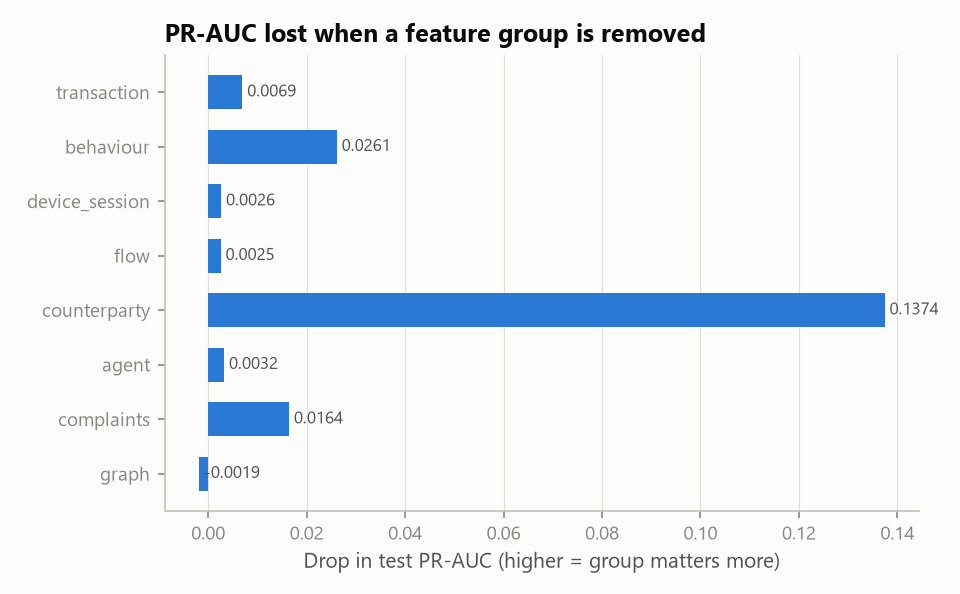

In [8]:
if m.get("ablation"):
    display(pd.DataFrame(m["ablation"]))
    display(pd.DataFrame(m["component_ablation"]))
    display(Image(filename=str(REPORTS / "figures" / "ablation_pr_auc_drop.png")))

## Explainability

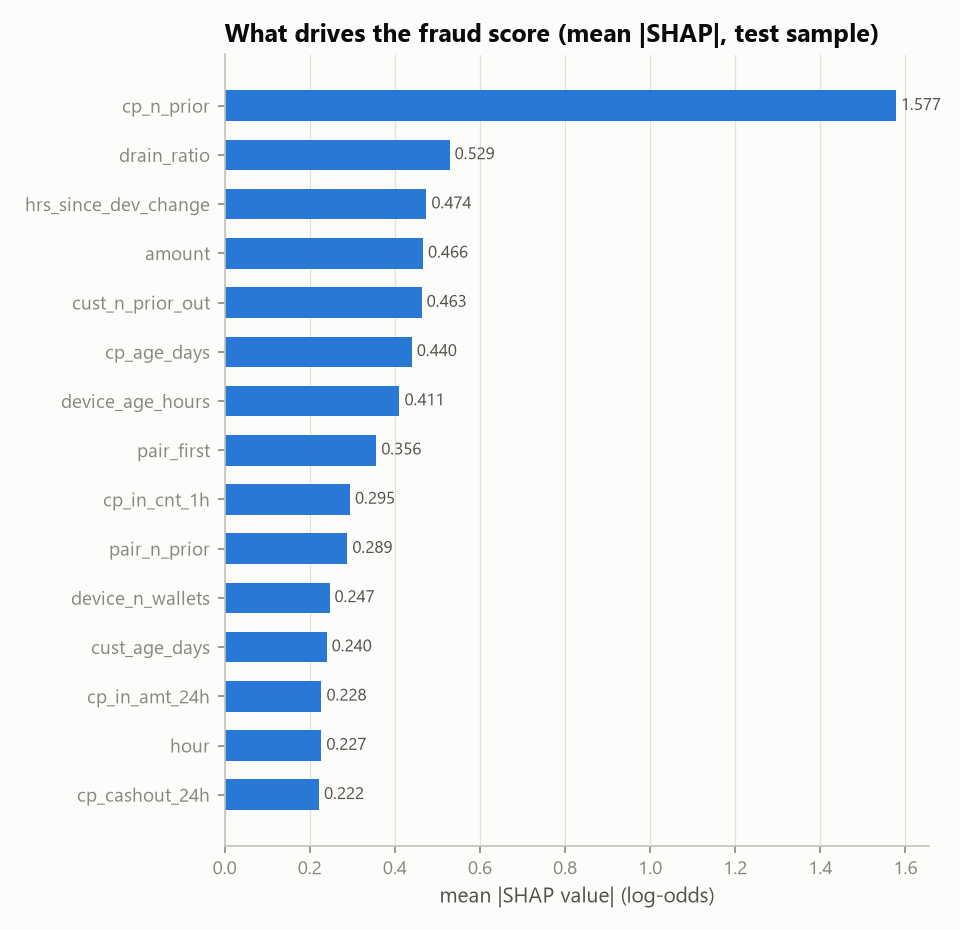

# Planted demo scenarios (test window, unseen by training)

| ID | Scenario | Expected | Actual | Score | Pass |
|---|---|---|---|---|---|
| SC-01 | SIM-swap takeover of a business owner at 01:40 | HOLD | HOLD | 100.0 | yes |
| SC-02 | Agent-register harvest: OTP takeover drains 12,500 to 4 mules in 30 s | STEP_UP | HOLD | 100.0 | yes |
| SC-03 | Collector wallet: 2 days old, 14 strangers paid it in 3 h; victim #15 about to send | STEP_UP | HOLD | 100.0 | yes |
| SC-04 | Mule chain through a 400-day-old dormant account (hops of 4, 6, 9 min) | STEP_UP | HOLD | 98.0 | yes |
| SC-05 | 'Jail guard' pressure scam: 60+ USSD farmer cashes in 20,000 and sends it | NUDGE | NUDGE | 30.5 | yes |
| SC-06 | Rogue agent: night cash-outs for the ring, ~8-10x peer volume | FLAGGED | FLAGGED | 85.8 | yes |
| SC-07 | Stolen card: 2 x 25,000 Add Money at 03:10, cash-out 29,500 at 03:40 | HOLD | HOLD | 100.0 | yes |
| SC-08 | Fake phone seller: 9 advance payments in 3 days; buyer #1 already reported it to 16268 | NUDGE | HOLD | 88.6 | yes |
| SB-01 | Busy shop owner's personal wallet: 12 payers in a day | ALLOW | ALLOW | 10.6 | yes |
| SB-02 | Legit new phone, then usual bill + 2,000 to mother | ALLOW | ALLOW | 15.3 | yes |
| SB-03 | Rent advance: 35,000 to a new landlord, Friday 11:00, own phone | NUDGE | STEP_UP (established parties cap) | 98.6 | yes |
| SB-04 | Student cashes out 4,900 twelve minutes after parent sends 5,000 | ALLOW | ALLOW | 0.2 | yes |
| SB-05 | Remittance family cashes out 29,500 twenty minutes after 48,250 lands | ALLOW | ALLOW | 2.4 | yes |

## SC-01: SIM-swap takeover of a business owner at 01:40
- txn `T00608619` (SEND_MONEY), band **HOLD**, score 100.0 (p_fraud 0.9999, anomaly 1.0, graph 0.0)
- A phone first seen on this account 0.1 hour(s) ago is being used  
  এই অ্যাকাউন্টে মাত্র ০.১ ঘণ্টা আগে নতুন ফোন থেকে লগইন হয়েছে
- The phone involved is used by 7 different wallets  
  সংশ্লিষ্ট ফোনটি ৭টি ভিন্ন ওয়ালেটে ব্যবহার হচ্ছে
- A wallet silent for 44 days suddenly became active  
  ৪৪ দিন নিষ্ক্রিয় থাকা ওয়ালেট হঠাৎ সক্রিয়
- Very unusual for this customer's own past behaviour (top 2% anomaly)  
  এই গ্রাহকের নিজের আগের আচরণের তুলনায় অত্যন্ত অস্বাভাবিক
- Customer sees: আপনার নিরাপত্তার জন্য লেনদেনটি সাময়িকভাবে স্থগিত রাখা হয়েছে। এই অ্যাকাউন্টে মাত্র ০.১ ঘণ্টা আগে নতুন ফোন থেকে লগইন হয়েছে। সংশ্লিষ্ট ফোনটি ৭টি ভিন্ন ওয়ালেটে ব্যবহার হচ্ছে। প্রয়োজনে ১৬২৬৮ নম্বরে কল করুন।
  (We have paused this transaction for your safety. A phone first seen on this account 0.1 hour(s) ago is being used. The phone involved is used by 7 different wallets. Call 16268 if you need help.)

## SC-02: Agent-register harvest: OTP takeover drains 12,500 to 4 mules in 30 s
- txn `T00605671` (SEND_MONEY), band **HOLD**, score 100.0 (p_fraud 0.9995, anomaly 0.953, graph 0.018)
- A phone first seen on this account 0.0 hour(s) ago is being used  
  এই অ্যাকাউন্টে মাত্র ০.০ ঘণ্টা আগে নতুন ফোন থেকে লগইন হয়েছে
- Recipient wallet was opened only 3 day(s) ago  
  এই নম্বরটি মাত্র ৩ দিন আগে খোলা হয়েছে
- You have never sent money to this number before  
  এই নম্বরে আপনি আগে কখনো টাকা পাঠাননি
- Customer sees: আপনার নিরাপত্তার জন্য লেনদেনটি সাময়িকভাবে স্থগিত রাখা হয়েছে। এই অ্যাকাউন্টে মাত্র ০.০ ঘণ্টা আগে নতুন ফোন থেকে লগইন হয়েছে। এই নম্বরটি মাত্র ৩ দিন আগে খোলা হয়েছে। প্রয়োজনে ১৬২৬৮ নম্বরে কল করুন।
  (We have paused this transaction for your safety. A phone first seen on this account 0.0 hour(s) ago is being used. Recipient wallet was opened only 3 day(s) ago. Call 16268 if you need help.)

## SC-03: Collector wallet: 2 days old, 14 strangers paid it in 3 h; victim #15 about to send
- txn `T00641926` (SEND_MONEY), band **HOLD**, score 100.0 (p_fraud 0.9995, anomaly 0.85, graph 0.995)
- 14 different people sent money to this number in the last 24 hours  
  গত ২৪ ঘণ্টায় ১৪ জন ভিন্ন মানুষ এই নম্বরে টাকা পাঠিয়েছেন
- Recipient wallet was opened only 2 day(s) ago  
  এই নম্বরটি মাত্র ২ দিন আগে খোলা হয়েছে
- Unusual time for this customer (12:00)  
  আপনার জন্য অস্বাভাবিক সময় (১২:০০)
- Part of a suspicious money-movement network (graph rules)  
  সন্দেহজনক টাকা লেনদেন নেটওয়ার্কের অংশ
- Customer sees: আপনার নিরাপত্তার জন্য লেনদেনটি সাময়িকভাবে স্থগিত রাখা হয়েছে। গত ২৪ ঘণ্টায় ১৪ জন ভিন্ন মানুষ এই নম্বরে টাকা পাঠিয়েছেন। এই নম্বরটি মাত্র ২ দিন আগে খোলা হয়েছে। প্রয়োজনে ১৬২৬৮ নম্বরে কল করুন।
  (We have paused this transaction for your safety. 14 different people sent money to this number in the last 24 hours. Recipient wallet was opened only 2 day(s) ago. Call 16268 if you need help.)

## SC-04: Mule chain through a 400-day-old dormant account (hops of 4, 6, 9 min)
- txn `T00633394` (SEND_MONEY), band **HOLD**, score 98.0 (p_fraud 0.9049, anomaly 0.998, graph 0.3)
- Recipient wallet was opened only 6 day(s) ago  
  এই নম্বরটি মাত্র ৬ দিন আগে খোলা হয়েছে
- Tk 19,500 is 1.0x the largest amount this customer has sent  
  ৳১৯,৫০০ আপনার আগের সর্বোচ্চ লেনদেনের ১.০ গুণ
- You have never sent money to this number before  
  এই নম্বরে আপনি আগে কখনো টাকা পাঠাননি
- Very unusual for this customer's own past behaviour (top 2% anomaly)  
  এই গ্রাহকের নিজের আগের আচরণের তুলনায় অত্যন্ত অস্বাভাবিক
- Customer sees: আপনার নিরাপত্তার জন্য লেনদেনটি সাময়িকভাবে স্থগিত রাখা হয়েছে। এই নম্বরটি মাত্র ৬ দিন আগে খোলা হয়েছে। ৳১৯,৫০০ আপনার আগের সর্বোচ্চ লেনদেনের ১.০ গুণ। প্রয়োজনে ১৬২৬৮ নম্বরে কল করুন।
  (We have paused this transaction for your safety. Recipient wallet was opened only 6 day(s) ago. Tk 19,500 is 1.0x the largest amount this customer has sent. Call 16268 if you need help.)

## SC-05: 'Jail guard' pressure scam: 60+ USSD farmer cashes in 20,000 and sends it
- txn `T00590040` (SEND_MONEY), band **NUDGE**, score 30.5 (p_fraud 0.0007, anomaly 0.871, graph 0.3)
- This moves 94% of the balance  
  আপনার ব্যালেন্সের ৯৪% পাঠানো হচ্ছে
- Tk 20,000 is 7.4x the largest amount this customer has sent  
  ৳২০,০০০ আপনার আগের সর্বোচ্চ লেনদেনের ৭.৪ গুণ
- You have never sent money to this number before  
  এই নম্বরে আপনি আগে কখনো টাকা পাঠাননি
- Customer sees: সতর্কতা: আপনার ব্যালেন্সের ৯৪% পাঠানো হচ্ছে। ৳২০,০০০ আপনার আগের সর্বোচ্চ লেনদেনের ৭.৪ গুণ। আপনি কি এই ব্যক্তিকে ব্যক্তিগতভাবে চেনেন?
  (Caution: This moves 94% of the balance. Tk 20,000 is 7.4x the largest amount this customer has sent. Do you personally know this person?)

## SC-07: Stolen card: 2 x 25,000 Add Money at 03:10, cash-out 29,500 at 03:40
- txn `T00629693` (CASH_OUT), band **HOLD**, score 100.0 (p_fraud 0.9998, anomaly 0.998, graph 0.3)
- The phone involved is used by 11 different wallets  
  সংশ্লিষ্ট ফোনটি ১১টি ভিন্ন ওয়ালেটে ব্যবহার হচ্ছে
- The sending wallet itself is only 4 day(s) old  
  প্রেরক ওয়ালেটটি মাত্র ৪ দিন পুরনো
- Money that arrived 26 minute(s) ago is being moved straight on  
  ২৬ মিনিট আগে আসা টাকা সাথে সাথে অন্যত্র সরানো হচ্ছে
- Very unusual for this customer's own past behaviour (top 2% anomaly)  
  এই গ্রাহকের নিজের আগের আচরণের তুলনায় অত্যন্ত অস্বাভাবিক
- Customer sees: আপনার নিরাপত্তার জন্য লেনদেনটি সাময়িকভাবে স্থগিত রাখা হয়েছে। সংশ্লিষ্ট ফোনটি ১১টি ভিন্ন ওয়ালেটে ব্যবহার হচ্ছে। প্রেরক ওয়ালেটটি মাত্র ৪ দিন পুরনো। প্রয়োজনে ১৬২৬৮ নম্বরে কল করুন।
  (We have paused this transaction for your safety. The phone involved is used by 11 different wallets. The sending wallet itself is only 4 day(s) old. Call 16268 if you need help.)

## SC-08: Fake phone seller: 9 advance payments in 3 days; buyer #1 already reported it to 16268
- txn `T00616551` (SEND_MONEY), band **HOLD**, score 88.6 (p_fraud 0.4655, anomaly 0.326, graph 0.6)
- Other customers have reported this number (or wallets it trades with) to 16268  
  অন্য গ্রাহকরা এই নম্বর বা এর সাথে লেনদেনকারী ওয়ালেটের বিরুদ্ধে ১৬২৬৮-এ অভিযোগ করেছেন
- Tk 6,000 is 1.0x the largest amount this customer has sent  
  ৳৬,০০০ আপনার আগের সর্বোচ্চ লেনদেনের ১.০ গুণ
- You have never sent money to this number before  
  এই নম্বরে আপনি আগে কখনো টাকা পাঠাননি
- Part of a suspicious money-movement network (graph rules)  
  সন্দেহজনক টাকা লেনদেন নেটওয়ার্কের অংশ
- Customer sees: আপনার নিরাপত্তার জন্য লেনদেনটি সাময়িকভাবে স্থগিত রাখা হয়েছে। অন্য গ্রাহকরা এই নম্বর বা এর সাথে লেনদেনকারী ওয়ালেটের বিরুদ্ধে ১৬২৬৮-এ অভিযোগ করেছেন। ৳৬,০০০ আপনার আগের সর্বোচ্চ লেনদেনের ১.০ গুণ। প্রয়োজনে ১৬২৬৮ নম্বরে কল করুন।
  (We have paused this transaction for your safety. Other customers have reported this number (or wallets it trades with) to 16268. Tk 6,000 is 1.0x the largest amount this customer has sent. Call 16268 if you need help.)

## SB-01: Busy shop owner's personal wallet: 12 payers in a day
- txn `T00625205` (SEND_MONEY), band **ALLOW**, score 10.6 (p_fraud 0.0002, anomaly 0.874, graph 0.0)
- 13 different people sent money to this number in the last 24 hours  
  গত ২৪ ঘণ্টায় ১৩ জন ভিন্ন মানুষ এই নম্বরে টাকা পাঠিয়েছেন

## SB-02: Legit new phone, then usual bill + 2,000 to mother
- txn `T00605254` (SEND_MONEY), band **ALLOW**, score 15.3 (p_fraud 0.0003, anomaly 0.663, graph 0.5)
- A phone first seen on this account 0.3 hour(s) ago is being used  
  এই অ্যাকাউন্টে মাত্র ০.৩ ঘণ্টা আগে নতুন ফোন থেকে লগইন হয়েছে
- The phone involved is used by 4 different wallets  
  সংশ্লিষ্ট ফোনটি ৪টি ভিন্ন ওয়ালেটে ব্যবহার হচ্ছে
- Part of a suspicious money-movement network (graph rules)  
  সন্দেহজনক টাকা লেনদেন নেটওয়ার্কের অংশ

## SB-03: Rent advance: 35,000 to a new landlord, Friday 11:00, own phone
- txn `T00588181` (SEND_MONEY), band **STEP_UP**, score 98.6 (p_fraud 0.9323, anomaly 0.997, graph 0.0)
- Tk 35,000 is 3.7x the largest amount this customer has sent  
  ৳৩৫,০০০ আপনার আগের সর্বোচ্চ লেনদেনের ৩.৭ গুণ
- You have never sent money to this number before  
  এই নম্বরে আপনি আগে কখনো টাকা পাঠাননি
- This moves 74% of the balance  
  আপনার ব্যালেন্সের ৭৪% পাঠানো হচ্ছে
- Very unusual for this customer's own past behaviour (top 2% anomaly)  
  এই গ্রাহকের নিজের আগের আচরণের তুলনায় অত্যন্ত অস্বাভাবিক
- Customer sees: নিশ্চিত করতে আবার পিন দিন। ৳৩৫,০০০ আপনার আগের সর্বোচ্চ লেনদেনের ৩.৭ গুণ। এই নম্বরে আপনি আগে কখনো টাকা পাঠাননি। upay কখনো ফোনে পিন বা ওটিপি চায় না।
  (Please confirm with your PIN. Tk 35,000 is 3.7x the largest amount this customer has sent. You have never sent money to this number before. upay never asks for your PIN or OTP on a call.)

## SB-04: Student cashes out 4,900 twelve minutes after parent sends 5,000
- txn `T00609423` (CASH_OUT), band **ALLOW**, score 0.2 (p_fraud 0.0, anomaly 0.825, graph 0.3)
- Tk 4,900 is 3.2x the largest amount this customer has sent  
  ৳৪,৯০০ আপনার আগের সর্বোচ্চ লেনদেনের ৩.২ গুণ
- Unusual time for this customer (10:00)  
  আপনার জন্য অস্বাভাবিক সময় (১০:০০)
- Money that arrived 12 minute(s) ago is being moved straight on  
  ১২ মিনিট আগে আসা টাকা সাথে সাথে অন্যত্র সরানো হচ্ছে

## SB-05: Remittance family cashes out 29,500 twenty minutes after 48,250 lands
- txn `T00633934` (CASH_OUT), band **ALLOW**, score 2.4 (p_fraud 0.0, anomaly 0.928, graph 0.3)
- Money that arrived 20 minute(s) ago is being moved straight on  
  ২০ মিনিট আগে আসা টাকা সাথে সাথে অন্যত্র সরানো হচ্ছে
- Tk 29,500 is 1.7x the largest amount this customer has sent  
  ৳২৯,৫০০ আপনার আগের সর্বোচ্চ লেনদেনের ১.৭ গুণ
- Unusual time for this customer (16:00)  
  আপনার জন্য অস্বাভাবিক সময় (১৬:০০)


In [9]:
display(Image(filename=str(REPORTS / "figures" / "shap_global_top15.png")))
display(Markdown((REPORTS / "demo_scenarios.md").read_text(encoding="utf-8")))